# Probe Training & Permutation Tests — Llama-3.2-3B

Trains Probe 1 (Mode 1 — ordering direction) and Probe 2 (Mode 2 — ordering
necessity) on the ProScript v1a training set using **Llama-3.2-3B**
(`meta-llama/Llama-3.2-3B-Instruct`). Performs a **full layer sweep across all 28 layers**
(0–27) to identify where procedural ordering knowledge is encoded,
rather than restricting to a pre-hypothesised window.

**Required:** `train.jsonl`, `dev.jsonl` in `/content/`.

**Outputs:** `probe_manifest.json`, `probe1_layer<N>.pkl`, `probe2_layer<N>.pkl`,
`probe1_layer_sweep.csv`, `probe2_layer_sweep.csv`,
`permutation_aucs_probe1.csv`, `permutation_aucs_probe2.csv`,
`layer_sweep.png`, `permutation_test.png`


In [ ]:
import subprocess, osimport osfrom huggingface_hub import loginlogin(token=os.getenv("HF_TOKEN", ""))subprocess.run(['pip','install','-q','transformers','accelerate',                'scikit-learn','tqdm','matplotlib'], check=True)os.makedirs('/content/cache', exist_ok=True)for f in ['train.jsonl','dev.jsonl']:    assert os.path.exists(f'/content/{f}'), f'Missing: {f}'print('All set: train.jsonl and dev.jsonl present (test.jsonl not required)')

All set: train.jsonl and dev.jsonl present (test.jsonl not required)


In [ ]:
import random, hashlib, json as _json
import numpy as np, pandas as pd
from pathlib import Path
CONTENT = Path('/content')

cfg = {
    'model_name':   'meta-llama/Llama-3.2-3B-Instruct',
    'sweep_layers': list(range(28)),  # full sweep: all 28 layers
    'n_perms':      30,
    'n_cv_folds':   5,
    'chat_template':True,
    'seed':         42,
    'use_cache':    True,
}
SEED = cfg['seed']

_cache_sig = hashlib.md5(
    _json.dumps({k: cfg[k] for k in
                 ['model_name','sweep_layers','chat_template','seed']},
                sort_keys=True).encode()
).hexdigest()[:10]
print(f'Config ready | model: {cfg["model_name"]} | layers: 0-27 (28 total) | '
      f'n_perms: {cfg["n_perms"]} | cache sig: {_cache_sig}')


Config ready | model: meta-llama/Llama-3.2-3B-Instruct | layers: 0-27 (28 total) | n_perms: 30 | cache sig: 5fbfb116f4


In [ ]:
import json as _json
from collections import defaultdict, deque

def load_jsonl_full(path):
    plans, seen = {}, set()
    with open(path, encoding='utf-8-sig') as f:
        for i, line in enumerate(f):
            line = line.strip()
            if not line: continue
            d = _json.loads(line)
            goal = d.get('scenario') or d.get('goal') or d.get('id', f'plan_{i}')
            if goal in seen:
                goal = f'{goal}__dup{i}'
            seen.add(goal)
            plans[goal] = d
    return plans

def parse_plan(d):
    raw_steps = d.get('events') or d.get('steps', {})
    steps = {int(k): v.strip() for k, v in raw_steps.items()}
    sentinels = {k for k, v in steps.items()
                 if v.upper() in ('START', 'END', 'NONE')}
    real = sorted([k for k in steps if k not in sentinels])
    adj = defaultdict(list)
    id_edges = []
    raw_edges = d.get('gold_edges_for_prediction') or d.get('edges', [])
    for e in raw_edges:
        if isinstance(e, str):
            parts = e.split('->')
            if len(parts) != 2: continue
            a, b = int(parts[0]), int(parts[1])
        elif isinstance(e, (list, tuple)):
            a, b = int(e[0]), int(e[1])
        else:
            continue
        if a in sentinels or b in sentinels: continue
        if a in steps and b in steps:
            adj[a].append(b)
            id_edges.append((a, b))
    return steps, id_edges, adj, real

def _reach(start, adj):
    v, q = set(), [start]
    while q:
        n = q.pop()
        for nb in adj.get(n, []):
            if nb not in v: v.add(nb); q.append(nb)
    return v

def get_incomparable(real, adj):
    r = {n: _reach(n, adj) for n in real}
    return [(real[i], real[j])
            for i in range(len(real))
            for j in range(i+1, len(real))
            if real[j] not in r[real[i]] and real[i] not in r[real[j]]]

def compute_depths(real, adj):
    in_deg = {s:0 for s in real}
    for n in real:
        for nb in adj.get(n,[]): in_deg[nb]=in_deg.get(nb,0)+1
    depth = {s:0 for s in real}
    q = deque([s for s in real if in_deg.get(s,0)==0])
    while q:
        n = q.popleft()
        for nb in adj.get(n,[]):
            depth[nb] = max(depth[nb], depth[n]+1)
            in_deg[nb] -= 1
            if in_deg[nb]==0: q.append(nb)
    return depth

print('Utils ready (full-load JSON parser)')


Utils ready (full-load JSON parser)


In [ ]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM

def wrap(raw):
    """Apply Llama-3.2-3B chat template to a raw prompt string."""
    messages = [{'role': 'user', 'content': raw.strip()}]
    return tokenizer.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True)

def tp1_direction(goal, a, b):
    return wrap(
        f'You are judging a temporal dependency between two actions in a task.\n'
        f'Task: {goal}\nAction A: {a}\nAction B: {b}\n'
        f'Question: Must Action A happen before Action B? '
        f'Answer yes or no.\nAnswer:')

def tp2_necessity(goal, a, b):
    return wrap(
        f'You are examining two actions in a task to see if they can be done in any order.\n'
        f'Task: {goal}\nStep A: {a}\nStep B: {b}\n'
        f'Question: Could A and B happen in either order without affecting the task, '
        f'or is one order strictly required? '
        f'Answer yes (flexible) or no (required).\nAnswer:')

def _single_token_ids(variants, tok):
    ids = set()
    for text in variants:
        enc = tok.encode(text, add_special_tokens=False)
        if len(enc) == 1:
            ids.add(enc[0])
        else:
            print(f'  WARNING: "{text}" encodes to {len(enc)} tokens, skipped')
    return sorted(ids)

print(f'Loading {cfg["model_name"]} ...')
tokenizer = AutoTokenizer.from_pretrained(cfg['model_name'])
model = AutoModelForCausalLM.from_pretrained(
    cfg['model_name'], torch_dtype=torch.float16,
    device_map='auto', output_hidden_states=True)
model.eval()

YES_IDS = _single_token_ids([' yes','yes','Yes',' Yes'], tokenizer)
NO_IDS  = _single_token_ids([' no', 'no', 'No', ' No'], tokenizer)
print(f'YES tokens: {YES_IDS}  |  NO tokens: {NO_IDS}')


Loading meta-llama/Llama-3.2-3B-Instruct ...


config.json:   0%|          | 0.00/878 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/54.5k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.09M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/296 [00:00<?, ?B/s]

...

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

[transformers] The following generation flags are not valid and may be ignored: ['output_hidden_states']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Loading weights:   0%|          | 0/254 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/189 [00:00<?, ?B/s]

YES tokens: [7566, 9642, 9891, 10035]  |  NO tokens: [912, 2201, 2360, 2822]


In [ ]:
import pickle

@torch.no_grad()
def get_layers_and_pyes(prompt):
    inputs = tokenizer(prompt, return_tensors='pt').to(model.device)
    out    = model(**inputs, output_hidden_states=True)
    hiddens = [out.hidden_states[l][0,-1].float().cpu().numpy()
               for l in cfg['sweep_layers']]
    probs   = torch.softmax(out.logits[0,-1].float(), dim=-1).cpu()
    p_yes   = sum(probs[i].item() for i in YES_IDS)
    p_no    = sum(probs[i].item() for i in NO_IDS)
    denom   = p_yes + p_no if (p_yes + p_no) > 0 else 1.0
    del out                  # free full hidden-states tuple immediately
    torch.cuda.empty_cache() # return GPU memory before next forward pass
    return hiddens, p_yes / denom

def _cpath(tag): return CONTENT / 'cache' / f'{tag}_{_cache_sig}.pkl'

def save_cache(tag, d):
    pickle.dump(d, open(_cpath(tag), 'wb'))
    print(f'  Cached: {_cpath(tag).name}')

def load_cache(tag): return pickle.load(open(_cpath(tag), 'rb'))
def has_cache(tag):  return _cpath(tag).exists()

print('Feature helpers ready')


Feature helpers ready


In [ ]:
from tqdm.auto import tqdm

train_plans = load_jsonl_full(CONTENT / 'train.jsonl')
dev_plans   = load_jsonl_full(CONTENT / 'dev.jsonl')
print(f'Loaded train: {len(train_plans)} plans  |  dev: {len(dev_plans)} plans')

eval_goals = set(dev_plans)

def build_rows(plans, exclude=None):
    p1, p2 = [], []
    for goal, d in tqdm(plans.items(), desc='Building rows', leave=False):
        if exclude and goal in exclude: continue
        steps, edges, adj, real = parse_plan(d)
        if not real or not edges: continue
        depths   = compute_depths(real, adj)
        incompat = get_incomparable(real, adj)
        for a_id, b_id in edges:
            a_t, b_t = steps[a_id], steps[b_id]
            p1.append({'goal':goal,'a':a_t,'b':b_t,'label':1})
            p1.append({'goal':goal,'a':b_t,'b':a_t,'label':0})
            p2.append({'goal':goal,'a':a_t,'b':b_t,'label':1})
        for ai, bi in incompat:
            a_t, b_t = steps[ai], steps[bi]
            p1.append({'goal':goal,'a':a_t,'b':b_t,'label':0})
            p1.append({'goal':goal,'a':b_t,'b':a_t,'label':0})
            if depths.get(ai) == depths.get(bi):
                p2.append({'goal':goal,'a':a_t,'b':b_t,'label':0})
                p2.append({'goal':goal,'a':b_t,'b':a_t,'label':0})
    return pd.DataFrame(p1), pd.DataFrame(p2)

def balance(df):
    pos = df[df.label==1]; neg = df[df.label==0]
    n   = min(len(pos), len(neg))
    return pd.concat([pos.sample(n,random_state=SEED),
                      neg.sample(n,random_state=SEED)],
                     ignore_index=True
                    ).sample(frac=1,random_state=SEED).reset_index(drop=True)

p1_train_raw, p2_train_raw = build_rows(train_plans, exclude=eval_goals)
p1_train = balance(p1_train_raw)
p2_train = balance(p2_train_raw)

p1_dev_raw, p2_dev_raw = build_rows(dev_plans)
p1_dev = p1_dev_raw.sample(frac=1, random_state=SEED).reset_index(drop=True)
p2_dev = p2_dev_raw.sample(frac=1, random_state=SEED).reset_index(drop=True)

print(f'Probe 1 -- train: {len(p1_train)} (balanced)  dev: {len(p1_dev)} (all)')
print(f'Probe 2 -- train: {len(p2_train)} (balanced)  dev: {len(p2_dev)} (all)')


Loaded train: 3252 plans  |  dev: 1085 plans


Building rows:   0%|          | 0/3252 [00:00<?, ?it/s]

Building rows:   0%|          | 0/1085 [00:00<?, ?it/s]

Probe 1 -- train: 41126 (balanced)  dev: 15342 (all)
Probe 2 -- train: 6672 (balanced)  dev: 7954 (all)


---
## Feature extraction

Each mode uses its own dedicated prompt: Probe 1 examples are encoded with
`tp1_direction` (the ordering-direction question), Probe 2 examples are encoded
with `tp2_necessity` (the ordering-necessity question). One forward pass per
example captures hidden states at every sweep layer simultaneously.


In [ ]:
def extract(df, tag, prompt_fn):
    if cfg['use_cache'] and has_cache(tag):
        print(f'  Loading cache: {_cpath(tag).name}')
        return load_cache(tag)
    rows = []
    for _, r in tqdm(df.iterrows(), total=len(df), desc=tag):
        hiddens, p_yes = get_layers_and_pyes(prompt_fn(r.goal, r.a, r.b))
        rows.append({'hiddens':hiddens, 'p_yes':p_yes,
                     'label':r.label, 'goal':r.goal})
    save_cache(tag, rows)
    return rows

p1_tr_feats = extract(p1_train, 'p1_train', tp1_direction)
p2_tr_feats = extract(p2_train, 'p2_train', tp2_necessity)
p1_dv_feats = extract(p1_dev,   'p1_dev',   tp1_direction)
p2_dv_feats = extract(p2_dev,   'p2_dev',   tp2_necessity)
print(f'Done: {len(p1_tr_feats)} p1_train / {len(p1_dv_feats)} p1_dev')
print(f'Done: {len(p2_tr_feats)} p2_train / {len(p2_dv_feats)} p2_dev')


p1_train:   0%|          | 0/41126 [00:00<?, ?it/s]

  Cached: p1_train_5fbfb116f4.pkl


p2_train:   0%|          | 0/6672 [00:00<?, ?it/s]

  Cached: p2_train_5fbfb116f4.pkl


p1_dev:   0%|          | 0/15342 [00:00<?, ?it/s]

  Cached: p1_dev_5fbfb116f4.pkl


p2_dev:   0%|          | 0/7954 [00:00<?, ?it/s]

  Cached: p2_dev_5fbfb116f4.pkl
Done: 41126 p1_train / 15342 p1_dev
Done: 6672 p2_train / 7954 p2_dev


---
## Layer sweep (15-18 only) with LLM baseline comparison

Probes are fitted on training features and evaluated on dev features, restricted
to the 15-18 consensus zone. Each probe's mode-specific LLM baseline (`p_yes`
from the same prompt) is computed alongside it for direct comparison.


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import roc_auc_score

def make_probe():
    return make_pipeline(
        StandardScaler(),
        LogisticRegression(C=1.0, max_iter=2000, class_weight='balanced'))

def llm_baseline_auc(dv_feats):
    y  = np.array([r['label'] for r in dv_feats])
    py = np.array([r['p_yes'] for r in dv_feats])
    return roc_auc_score(y, py)

def sweep(tr_feats, dv_feats, name):
    y_tr = np.array([r['label'] for r in tr_feats])
    y_dv = np.array([r['label'] for r in dv_feats])
    dv_goals = np.array([r['goal'] for r in dv_feats])
    llm_auc  = llm_baseline_auc(dv_feats)

    rows, best_auc, best_layer = [], -1, None
    for li, layer in enumerate(cfg['sweep_layers']):
        X_tr = np.array([r['hiddens'][li] for r in tr_feats])
        X_dv = np.array([r['hiddens'][li] for r in dv_feats])
        probe = make_probe()
        probe.fit(X_tr, y_tr)
        proba_dv = probe.predict_proba(X_dv)[:, 1]
        dev_auc  = roc_auc_score(y_dv, proba_dv)

        plan_aucs = []
        for g in set(dv_goals):
            mask = dv_goals == g
            if len(set(y_dv[mask])) < 2: continue
            plan_aucs.append(roc_auc_score(y_dv[mask], proba_dv[mask]))
        macro_auc = float(np.mean(plan_aucs)) if plan_aucs else float('nan')

        marker = '  <- best' if dev_auc > best_auc else ''
        print(f'  Layer {layer:2d}: probe AUC {dev_auc:.4f}  '
              f'macro {macro_auc:.4f}  |  LLM AUC {llm_auc:.4f}  '
              f'(margin +{dev_auc-llm_auc:.4f}){marker}')
        rows.append({'layer':layer, 'probe_auc':round(dev_auc,4),
                     'macro_auc':round(macro_auc,4),
                     'llm_auc':round(llm_auc,4),
                     'margin':round(dev_auc-llm_auc,4)})
        if dev_auc > best_auc:
            best_auc, best_layer = dev_auc, layer

    df = pd.DataFrame(rows)
    df.to_csv(CONTENT / f'{name}_layer_sweep.csv', index=False)
    return df, best_layer, best_auc, llm_auc

print('=== Probe 1 layer sweep (direction task) ===')
p1_sweep, p1_best, p1_auc, p1_llm_auc = sweep(p1_tr_feats, p1_dv_feats, 'probe1')
print(f'\nBest layer: {p1_best}  probe AUC {p1_auc:.4f}  '
      f'LLM AUC {p1_llm_auc:.4f}  margin +{p1_auc-p1_llm_auc:.4f}\n')

print('=== Probe 2 layer sweep (necessity task) ===')
p2_sweep, p2_best, p2_auc, p2_llm_auc = sweep(p2_tr_feats, p2_dv_feats, 'probe2')
print(f'\nBest layer: {p2_best}  probe AUC {p2_auc:.4f}  '
      f'LLM AUC {p2_llm_auc:.4f}  margin +{p2_auc-p2_llm_auc:.4f}')


=== Probe 1 layer sweep (direction task) ===
  Layer  0: probe AUC 0.5000  macro 0.5000  |  LLM AUC 0.5699  (margin +-0.0699)  <- best


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


  Layer  1: probe AUC 0.5613  macro 0.5660  |  LLM AUC 0.5699  (margin +-0.0086)  <- best
  Layer  2: probe AUC 0.5794  macro 0.5886  |  LLM AUC 0.5699  (margin +0.0095)  <- best
  Layer  3: probe AUC 0.6273  macro 0.6573  |  LLM AUC 0.5699  (margin +0.0574)  <- best
  Layer  4: probe AUC 0.6679  macro 0.6976  |  LLM AUC 0.5699  (margin +0.0979)  <- best
  Layer  5: probe AUC 0.6806  macro 0.7130  |  LLM AUC 0.5699  (margin +0.1107)  <- best
  Layer  6: probe AUC 0.6898  macro 0.7240  |  LLM AUC 0.5699  (margin +0.1198)  <- best
  Layer  7: probe AUC 0.6972  macro 0.7408  |  LLM AUC 0.5699  (margin +0.1273)  <- best
  Layer  8: probe AUC 0.7278  macro 0.7673  |  LLM AUC 0.5699  (margin +0.1579)  <- best
  Layer  9: probe AUC 0.7499  macro 0.7967  |  LLM AUC 0.5699  (margin +0.1799)  <- best
  Layer 10: probe AUC 0.7732  macro 0.8235  |  LLM AUC 0.5699  (margin +0.2033)  <- best
  Layer 11: probe AUC 0.8023  macro 0.8427  |  LLM AUC 0.5699  (margin +0.2323)  <- best
  Layer 12: probe AU

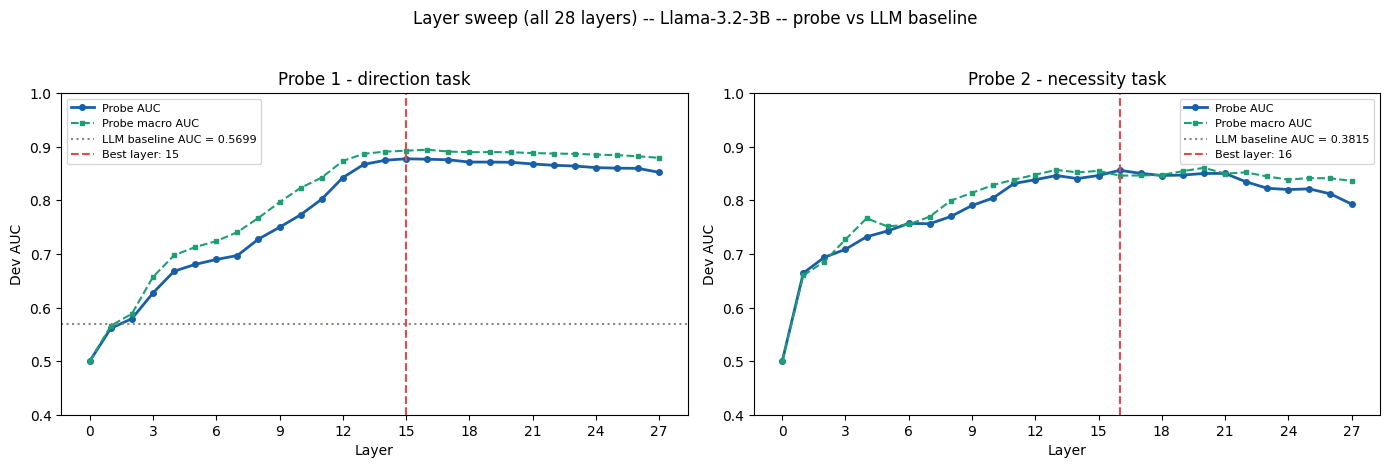

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
for ax, sw, best, llm_auc, title in [
    (axes[0], p1_sweep, p1_best, p1_llm_auc, 'Probe 1 - direction task'),
    (axes[1], p2_sweep, p2_best, p2_llm_auc, 'Probe 2 - necessity task')]:
    ax.plot(sw.layer, sw.probe_auc, 'o-', color='#185FA5', lw=2, ms=4,
            label='Probe AUC')
    ax.plot(sw.layer, sw.macro_auc, 's--', color='#1D9E75', lw=1.5, ms=3,
            label='Probe macro AUC')
    ax.axhline(llm_auc, color='#888780', lw=1.5, ls=':',
               label=f'LLM baseline AUC = {llm_auc:.4f}')
    ax.axvline(best, color='#E24B4A', lw=1.5, ls='--', label=f'Best layer: {best}')
    ax.set_xlabel('Layer'); ax.set_ylabel('Dev AUC')
    ax.set_title(title); ax.legend(fontsize=8); ax.set_ylim(0.4, 1.0)
    # Show every 4th layer label to avoid crowding on full sweep
    tick_step = max(1, 28 // 8)
    ax.set_xticks([l for l in range(28) if l % tick_step == 0])
plt.suptitle('Layer sweep (all 28 layers) -- Llama-3.2-3B -- probe vs LLM baseline', y=1.03)
plt.tight_layout()
plt.savefig(CONTENT/'layer_sweep.png', dpi=130, bbox_inches='tight')
plt.show()


In [ ]:
import pickle, json as _json

def train_final(tr_feats, best_layer, name):
    li = cfg['sweep_layers'].index(best_layer)
    X  = np.array([r['hiddens'][li] for r in tr_feats])
    y  = np.array([r['label']       for r in tr_feats])
    probe = make_probe()
    probe.fit(X, y)
    lr = probe.named_steps['logisticregression']
    if lr.n_iter_[0] >= lr.max_iter:
        print(f'  WARNING: {name} did not converge in {lr.max_iter} iterations')
    out = CONTENT / f'{name}_layer{best_layer}.pkl'
    pickle.dump({
        'probe': probe, 'layer': best_layer,
        'model_name': cfg['model_name'],
        'sweep_layers': cfg['sweep_layers'],
        'n_train': len(X), 'feature_dim': X.shape[1],
    }, open(out, 'wb'))
    print(f'  Saved {out.name}')
    return probe

probe1 = train_final(p1_tr_feats, p1_best, 'probe1')
probe2 = train_final(p2_tr_feats, p2_best, 'probe2')

manifest = {
    'probe1_file': f'probe1_layer{p1_best}.pkl', 'probe1_layer': p1_best,
    'probe2_file': f'probe2_layer{p2_best}.pkl', 'probe2_layer': p2_best,
    'model_name': cfg['model_name'],
    'cache_sig': _cache_sig,
    'prompt_mode1': 'tp1_direction',
    'prompt_mode2': 'tp2_necessity',
}
_json.dump(manifest, open(CONTENT/'probe_manifest.json','w'), indent=2)
print(f'Manifest saved: {manifest}')


  Saved probe1_layer15.pkl
  Saved probe2_layer16.pkl
Manifest saved: {'probe1_file': 'probe1_layer15.pkl', 'probe1_layer': 15, 'probe2_file': 'probe2_layer16.pkl', 'probe2_layer': 16, 'model_name': 'meta-llama/Llama-3.2-3B-Instruct', 'cache_sig': '5fbfb116f4', 'prompt_mode1': 'tp1_direction', 'prompt_mode2': 'tp2_necessity'}


---
## Permutation tests (reduced count)

**Scope:** group-CV permutation test at the fixed layers selected on the
development set. With `n_perms=30`, the minimum reportable p-value is
1/31 ~ 0.032 -- still below the conventional 0.05 significance threshold.
Given the AUC gaps observed in prior runs (real ~0.82-0.88 vs permuted ~0.50,
a 0.3+ gap), 100 permutations was far more than needed; 30 is sufficient to
show 0/30 permuted runs reaching the real AUC.

**Exchangeability note:** labels are permuted globally across rows, which does
not preserve within-plan correlation structure. This is a standard approximation;
the test remains informative as evidence the probe exploits real feature-label
correspondence rather than fitting noise.


In [ ]:
from sklearn.model_selection import GroupKFold

NUM_PERM_FOLDS = 3
gkf      = GroupKFold(n_splits=NUM_PERM_FOLDS)
rng_perm = np.random.default_rng(SEED)

def permutation_test(tr_feats, best_layer, name):
    li     = cfg['sweep_layers'].index(best_layer)
    X_raw  = np.array([r['hiddens'][li] for r in tr_feats])
    y      = np.array([r['label']       for r in tr_feats])
    groups = np.array([r['goal']        for r in tr_feats])

    scaler = StandardScaler()
    X = scaler.fit_transform(X_raw)

    MAX_PERM_ROWS = 5000
    if len(X) > MAX_PERM_ROWS:
        idx = np.random.default_rng(SEED).choice(
            len(X), MAX_PERM_ROWS, replace=False)
        X_p, y_p, g_p = X[idx], y[idx], groups[idx]
        print(f'  Subsampled {len(X)} -> {MAX_PERM_ROWS} for permutation test')
    else:
        X_p, y_p, g_p = X, y, groups

    def cv_auc(labels):
        fold_aucs = []
        for tr, val in gkf.split(X_p, labels, groups=g_p):
            if len(set(labels[val])) < 2: continue
            if len(set(labels[tr]))  < 2: continue
            lr = LogisticRegression(C=1.0, max_iter=1000,
                                    class_weight='balanced', solver='lbfgs')
            lr.fit(X_p[tr], labels[tr])
            fold_aucs.append(
                roc_auc_score(labels[val], lr.predict_proba(X_p[val])[:,1]))
        return float(np.mean(fold_aucs)) if fold_aucs else 0.5

    real_auc = cv_auc(y_p)
    perm_aucs = []
    for i in range(cfg['n_perms']):
        perm_aucs.append(cv_auc(rng_perm.permutation(y_p)))
        if (i+1) % 10 == 0:
            print(f'  [{name}] {i+1}/{cfg["n_perms"]}  '
                  f'perm mean: {np.mean(perm_aucs):.4f}')

    p_val = (1 + np.sum(np.array(perm_aucs) >= real_auc)) / (len(perm_aucs) + 1)
    pd.DataFrame({'perm_auc': perm_aucs}).to_csv(
        CONTENT / f'permutation_aucs_{name}.csv', index=False)
    return real_auc, perm_aucs, float(p_val)

print('=== Probe 1 permutation test ===')
p1_real, p1_perms, p1_pval = permutation_test(p1_tr_feats, p1_best, 'probe1')
print(f'  Real {p1_real:.4f}  perm mean {np.mean(p1_perms):.4f}  p={p1_pval:.4f}\n')

print('=== Probe 2 permutation test ===')
p2_real, p2_perms, p2_pval = permutation_test(p2_tr_feats, p2_best, 'probe2')
print(f'  Real {p2_real:.4f}  perm mean {np.mean(p2_perms):.4f}  p={p2_pval:.4f}')


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, real, perms, pval, name, layer in [
    (axes[0], p1_real, p1_perms, p1_pval, 'Probe 1', p1_best),
    (axes[1], p2_real, p2_perms, p2_pval, 'Probe 2', p2_best)]:
    ax.hist(perms, bins=15, color='#888780', alpha=0.7,
            label=f'Permuted ({cfg["n_perms"]}x)')
    ax.axvline(real, color='#185FA5', lw=2.5, label=f'Real AUC = {real:.4f}')
    ax.axvline(np.mean(perms), color='#E24B4A', lw=1.5, ls='--',
               label=f'Perm mean = {np.mean(perms):.4f}')
    ax.set_xlabel('CV AUC'); ax.set_ylabel('Count')
    ax.set_title(f'{name} (layer {layer})')
    ax.legend(fontsize=9)
    min_p = 1/(cfg['n_perms']+1)
    lbl = f'p < {min_p*2:.3f}' if pval <= min_p*1.01 else f'p = {pval:.3f}'
    ax.text(0.98, 0.97, lbl, transform=ax.transAxes,
            ha='right', va='top', fontsize=10,
            color='#185FA5' if pval < 0.05 else '#888780')
plt.tight_layout()
plt.savefig(CONTENT/'permutation_test.png', dpi=130, bbox_inches='tight')
plt.show()


In [ ]:
print('=== SUMMARY ===')
print(f'Probe 1 (direction) | layer {p1_best} | dev AUC {p1_auc:.4f} | '
      f'LLM AUC {p1_llm_auc:.4f} | margin +{p1_auc-p1_llm_auc:.4f} | '
      f'perm p={p1_pval:.4f}')
print(f'Probe 2 (necessity) | layer {p2_best} | dev AUC {p2_auc:.4f} | '
      f'LLM AUC {p2_llm_auc:.4f} | margin +{p2_auc-p2_llm_auc:.4f} | '
      f'perm p={p2_pval:.4f}')
print()
print('Saved:')
for f in [f'probe1_layer{p1_best}.pkl', f'probe2_layer{p2_best}.pkl',
          'probe_manifest.json',
          'probe1_layer_sweep.csv', 'probe2_layer_sweep.csv',
          'permutation_aucs_probe1.csv', 'permutation_aucs_probe2.csv',
          'layer_sweep.png', 'permutation_test.png']:
    print(f'  {f}')
